In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import math
import json

# nbconvert sets cwd to the notebook's directory (plots/); fix it to scripts/
if not (Path.cwd() / 'plots').exists():
    os.chdir(Path.cwd().parent)

plt.style.use("./plots/latex_style.mplstyle")

SMOKE_TEST = os.environ.get("SMOKE_TEST", "0") == "1"
SMOKE_TEST = True

benches = ["ROVER", "Hydra", "Alive", "Industry"]
active_benches = ["Alive", "Hydra"] if SMOKE_TEST else benches

RESULTS_DIR = Path(os.environ.get("RESULTS_DIR", '../results')) if not SMOKE_TEST else Path("../smoke_test")

BENCH_BASE = Path("../benchmarks")

FIGURES_PATH = RESULTS_DIR / "plots"
TABLE_OUTPUT = RESULTS_DIR / "tables"

TIMEOUT = int(os.environ.get("TIMEOUT", '60_000'))  # timeout in milliseconds

os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(TABLE_OUTPUT, exist_ok=True)

parabit = {}
pbv = {}

for bench in active_benches:
    if bench in ("Alive", "Hydra"):
        pbv[bench] = pd.read_csv(f"{RESULTS_DIR}/pbv/{bench}/results.csv")
    else:
        pbv[bench] = pd.read_csv(f"{RESULTS_DIR}/pbv/{bench}/summary.csv")

for bench in active_benches:
    if bench == 'Industry':
        parabit[bench] = pd.read_csv(f"{RESULTS_DIR}/parabit/Cadence/results.csv")
    else:
        parabit[bench] = pd.read_csv(f"{RESULTS_DIR}/parabit/{bench}/results.csv")
    parabit[bench]["time_taken"] = (
        parabit[bench]["time_taken"] * 1000
    )  # convert seconds to milliseconds
    parabit[bench]["file"] = parabit[bench]["file"].str.replace(
        ".bwlang", "", regex=False
    )  # remove file extension
    if bench == "Hydra":
        parabit[bench]["file"] = parabit[bench]["file"].str.replace(
            "hydra_", "", regex=False
        )  # remove file extension
    parabit[bench].set_index("file")
    pbv[bench]["file"] = pbv[bench]["file"].str.replace(
        ".smt2", "", regex=False
    )  # remove file extension
    pbv[bench].set_index("file")

# pbv, parabit, mirabelle

In [2]:
datas = {}
for i, bench in enumerate(active_benches):
    all_names = set(parabit[bench]["file"]) | set(pbv[bench]["file"])

    data = pd.DataFrame()

    data["name"] = [x for x in all_names if type(x) is str]

    print(bench, len(data["name"]))

    if bench in ["Hydra", "Alive"]:
        filtered = pbv[bench][["time", "file", "result"]]
    else:
        filtered = pbv[bench][["unsat_time_average", "file", "result"]]
        filtered = filtered.rename(columns={"unsat_time_average": "time"})

    filtered["time"] *= 1000  # convert second to ms
    data = data.merge(filtered, left_on="name", right_on="file", how="left")
    data = data.rename(columns={"time": "pbv", "result": "pbv_result"}).drop(
        columns="file"
    )
    data["pbv_result"] = data["pbv_result"].map(
        {"unsat": True, "sat": False, "timeout": False, "error": False}
    )

    filtered = parabit[bench][["time_taken", "file", "status"]]
    data = data.merge(filtered, left_on="name", right_on="file", how="left")
    data = data.rename(
        columns={"time_taken": "parabit", "status": "parabit_result"}
    ).drop(columns="file")
    data["parabit_result"] = data["parabit_result"].map(
        {"SUCCESS": True, "FAILED": False}
    )

    datas[bench] = data

datas[active_benches[0]]

Alive 200
Hydra 154


,name,pbv,pbv_result,parabit,parabit_result
0,AndOrXor_1899_values_0,8.517905,True,NaN,NaN
1,AndOrXor_2595_values_0,28.735185,True,3.175251,True
2,AndOrXor_1870_values_0,10.123909,True,NaN,NaN
3,AndOrXor_1833_values_0,8.238739,True,NaN,NaN
4,InstCombineShift239_values_0,2000.000000,False,NaN,NaN
...,...,...,...,...,...
195,AndOrXor_2417_values_0,2000.000000,False,1.004594,True
196,Select_740_values_0,2000.000000,False,NaN,NaN
197,muldivrem_735b_values_0,2000.000000,False,NaN,NaN
198,AndOrXor_523_values_0,2000.000000,False,NaN,NaN


In [3]:
single_width = {}
multi_width = {}

for bench in active_benches:
    single_filename = BENCH_BASE / bench / "singlewidth.txt"
    with open(single_filename, "r") as f:
        filter_values = [l.strip() for l in f.readlines()]
        single_width[bench] = set(filter_values)

    multi_filename = BENCH_BASE / bench / "multiwidth.txt"
    with open(multi_filename, "r") as f:
        filter_values = [l.strip() for l in f.readlines()]
        multi_width[bench] = set(filter_values)

single = {
    "benchmark": ["unique", "solved", "total"],
    "pbv_full": [],
    "pbv_restricted": [],
    "parabit": [],
    "vbs": [],
}
multi = {
    "benchmark": ["unique", "solved", "total"],
    "pbv_full": [],
    "pbv_restricted": [],
    "parabit": [],
    "vbs": [],
}

for table in [single, multi]:
    for k in table:
        if k != "benchmark":
            table[k] = [0, 0, 0]

for bench in active_benches:
    data = datas[bench]
    sw = data["name"].isin(single_width[bench])
    mw = data["name"].isin(multi_width[bench])

    pb = ~data["parabit_result"].isna()
    pbv = ~data["pbv_result"].isna()
    restricted = pb & pbv
    both = (data["parabit_result"] & pb) | (data["pbv_result"] & pbv)

    single["benchmark"].append(bench)
    single["pbv_full"].append(
        f"{len(data[sw & data['pbv_result'] & pbv])}/{len(data[sw & pbv])}"
    )
    single["pbv_full"][2] += len(data[sw & pbv])
    single["pbv_full"][1] += len(data[sw & pbv & data["pbv_result"]])
    single["pbv_full"][0] += len(
        data[sw & data["pbv_result"] & (data["parabit_result"] != True)]
    )

    single["pbv_restricted"].append(
        f"{len(data[sw & data['pbv_result'] & restricted])}/{len(data[sw & restricted])}"
    )
    single["pbv_restricted"][2] += len(data[sw & restricted])
    single["pbv_restricted"][1] += len(data[sw & restricted & data["pbv_result"]])
    single["pbv_restricted"][0] += len(
        data[sw & restricted & data["pbv_result"] & (data["parabit_result"] != True)]
    )

    single["parabit"].append(
        f"{len(data[sw & data['parabit_result'] & pb])}/{len(data[sw & pb])}"
    )
    single["parabit"][2] += len(data[sw & pb])
    single["parabit"][1] += len(data[sw & data["parabit_result"] & pb])
    single["parabit"][0] += len(
        data[sw & data["parabit_result"] & pb & (data["pbv_result"] != True)]
    )

    single["vbs"].append(f"{len(data[sw & both])}/{len(data[sw])}")
    single["vbs"][2] += len(data[sw])
    single["vbs"][1] += len(data[sw & both])

    multi["benchmark"].append(bench)

    multi["pbv_full"].append(
        f"{len(data[mw & data['pbv_result'] & pbv])}/{len(data[mw & pbv])}"
    )
    multi["pbv_full"][2] += len(data[mw & pbv])
    multi["pbv_full"][1] += len(data[mw & pbv & data["pbv_result"]])
    multi["pbv_full"][0] += len(
        data[mw & data["pbv_result"] & (data["parabit_result"] != True)]
    )

    multi["pbv_restricted"].append(
        f"{len(data[mw & data['pbv_result'] & restricted])}/{len(data[mw & restricted])}"
    )
    multi["pbv_restricted"][2] += len(data[mw & restricted])
    multi["pbv_restricted"][1] += len(data[mw & restricted & data["pbv_result"]])
    multi["pbv_restricted"][0] += len(
        data[mw & restricted & data["pbv_result"] & (data["parabit_result"] != True)]
    )

    multi["parabit"].append(
        f"{len(data[mw & data['parabit_result'] & pb])}/{len(data[mw & pb])}"
    )
    multi["parabit"][2] += len(data[mw & pb])
    multi["parabit"][1] += len(data[mw & data["parabit_result"] & pb])
    multi["parabit"][0] += len(
        data[mw & data["parabit_result"] & pb & (data["pbv_result"] != True)]
    )

    multi["vbs"].append(f"{len(data[mw & both])}/{len(data[mw])}")
    multi["vbs"][2] += len(data[mw])
    multi["vbs"][1] += len(data[mw & both])

for table in [single, multi]:
    table['vbs'][0] = '-'
    for key in table:
        if key != "benchmark":
            table[key][1] = f"{table[key][1]/table[key][2]:.0%}"
        table[key].pop(2)
        table[key].append(table[key].pop(0))
        table[key].append(table[key].pop(0))

single_df = pd.DataFrame(single)
multi_df = pd.DataFrame(multi)

display(single_df)
display(multi_df)

,benchmark,pbv_full,pbv_restricted,parabit,vbs
0,Alive,103/196,31/61,53/61,129/196
1,Hydra,55/74,26/30,24/30,56/74
2,unique,108,7,27,-
3,solved,59%,63%,85%,69%


,benchmark,pbv_full,pbv_restricted,parabit,vbs
0,Alive,3/4,0/1,1/1,4/4
1,Hydra,33/75,9/40,32/40,56/75
2,unique,27,0,24,-
3,solved,46%,22%,80%,76%


In [4]:
# Save tables

table2_path = TABLE_OUTPUT / 'table2'
table2_path.mkdir(parents=True, exist_ok=True)
with open( table2_path / 'single.tex', 'w+') as f:
    single_df.to_latex(f, index=False)

with open( table2_path / 'multiple.tex', 'w+') as f:
    multi_df.to_latex(f, index=False)

with open(table2_path / 'combined.md', 'a+') as f:
    f.write('# Single Width\n')
    single_df.to_markdown(f, index=False)
    f.write('\n\n')
    f.write('# Multi Width\n')
    multi_df.to_markdown(f, index=False)


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


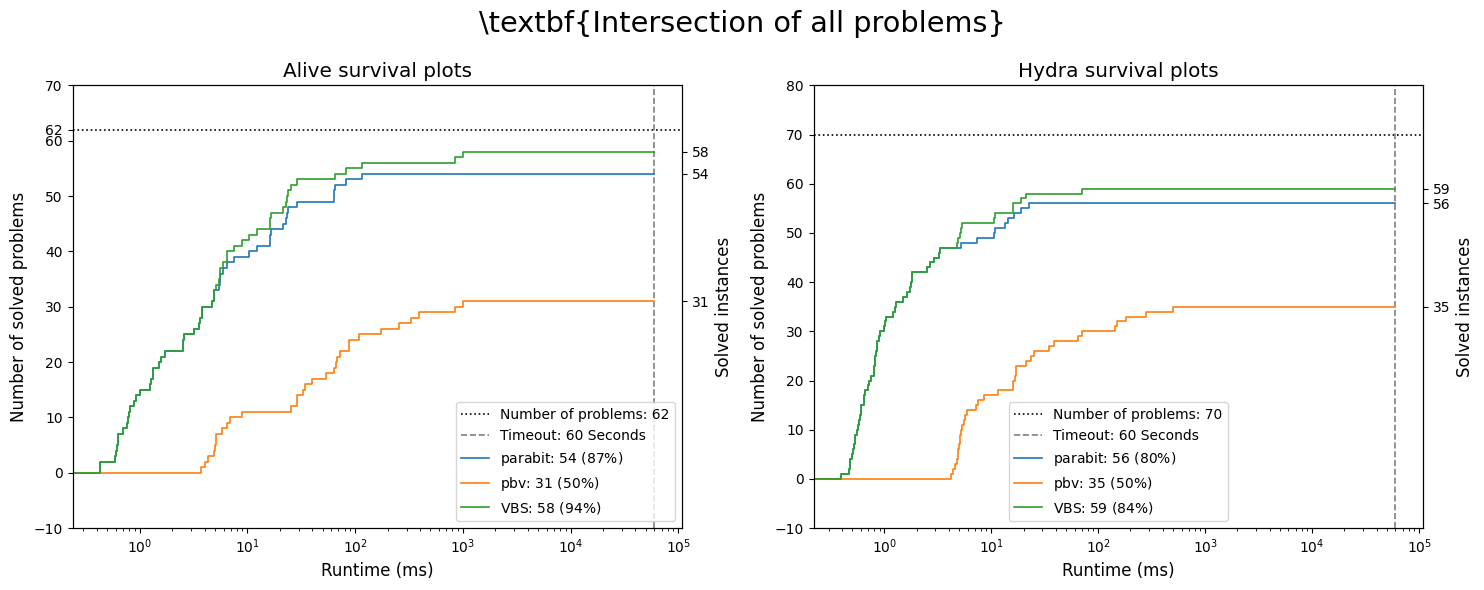

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

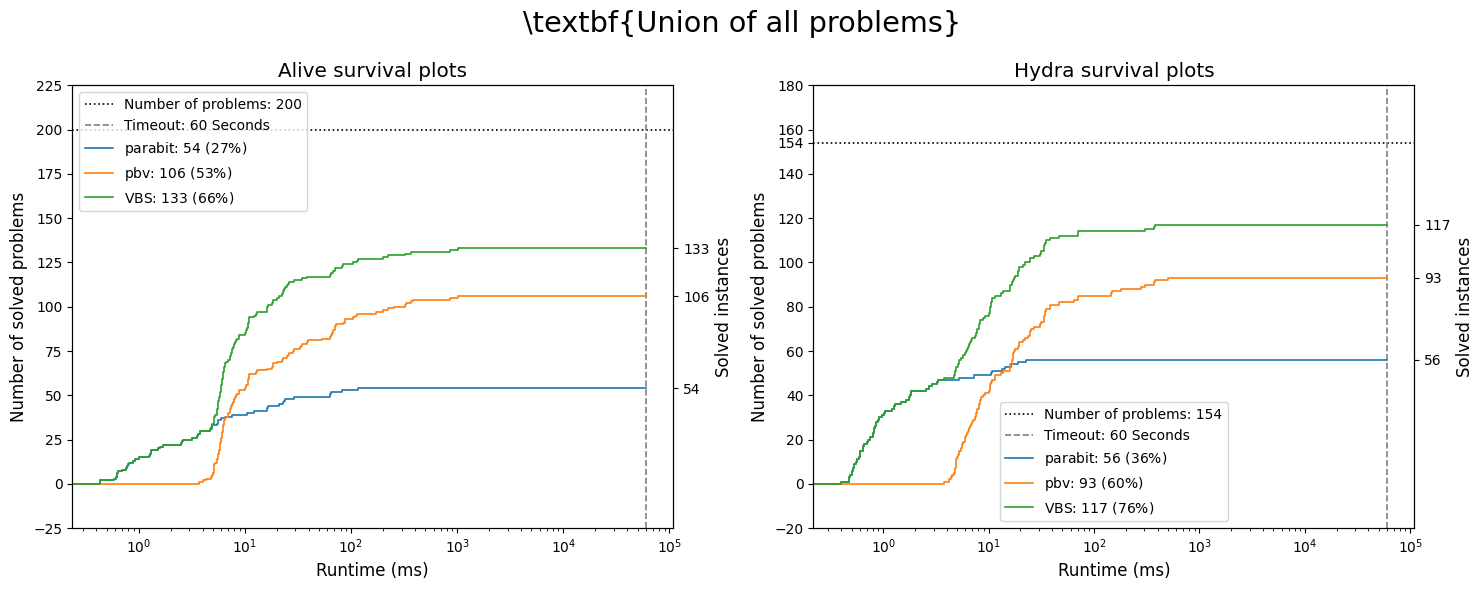

In [5]:
from plots.utils import combine_results, plot_cactus

n = len(active_benches)
n_cols = min(n, 2)
n_rows = math.ceil(n / n_cols)

def _axs_flat(axs, n):
    if n == 1:
        return [axs]
    return axs.flatten() if hasattr(axs, 'flatten') else list(axs)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows))
for ax_i, bench in enumerate(active_benches):
    data = datas[bench]
    data_tmp = data.copy()

    filter_frame = ~data_tmp['parabit_result'].isna() & ~data_tmp['pbv_result'].isna()
    data_tmp = data_tmp[filter_frame]

    data_tmp['parabit'] = data_tmp[data_tmp['parabit_result']]['parabit']
    data_tmp['pbv'] = data_tmp[data_tmp['pbv_result']]['pbv']

    data_tmp = data_tmp[['parabit', 'pbv']]
    data_tmp["VBS"] = data_tmp.apply(combine_results, axis=1)

    ax = _axs_flat(axs, n)[ax_i]
    plot_cactus(ax, data_tmp, TIMEOUT)
    ax.legend(loc="best")
    ax.set_title(f"{bench} survival plots")
fig.suptitle("\\textbf{Intersection of all problems}", fontsize="xx-large")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "Figure7.pdf")
plt.show()

fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows))
for ax_i, bench in enumerate(active_benches):
    data = datas[bench]
    data_tmp = data.copy()

    filter_frame = ~data_tmp['parabit_result'].isna() | ~data_tmp['pbv_result'].isna()
    data_tmp = data_tmp[filter_frame]

    data_tmp['parabit'] = data_tmp[~data_tmp['parabit_result'].isna() & data_tmp['parabit_result']]['parabit']
    data_tmp['pbv'] = data_tmp[~data_tmp['pbv_result'].isna() & data_tmp['pbv_result']]['pbv']

    data_tmp = data_tmp[['parabit', 'pbv']]
    data_tmp["VBS"] = data_tmp.apply(combine_results, axis=1)

    ax = _axs_flat(axs, n)[ax_i]
    plot_cactus(ax, data_tmp, TIMEOUT)
    ax.legend(loc="best")
    ax.set_title(f"{bench} survival plots")
fig.suptitle("\\textbf{Union of all problems}", fontsize="xx-large")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "Figure7_variant.pdf")
plt.show()

In [52]:
# Generate Table 3
data_out = {"benchmark" : [], "#_parabit": [], "Nodes" : [], "Classes": [], "Iterations": [], "Time(ms)": [], "Proof_len": [], "Time_w_Proof(ms)": [], "#_pbv": [], "PBV_Time(ms)":[]}

extra_info = ""

for bench in active_benches:
    data = datas[bench]
    solved_problems_mask = ~data['parabit_result'].isna() & data['parabit_result']
    solved_problems = data[solved_problems_mask]['name'].tolist()
    
    iterations_acc = 0
    eclass_acc = 0
    enode_acc = 0
    
    for prob in solved_problems:
        stats_file = RESULTS_DIR / 'parabit' / bench / 'logs' / f"{prob}.bwlang.stats.json"
        with open(stats_file, 'r') as f:
            stats = json.load(f)
            iterations_acc += stats[1]['summary']['iterations']
            enode_acc += stats[1]['summary']['egraph_nodes']
            eclass_acc += stats[1]['summary']['egraph_classes']
    
    iterations_avg = iterations_acc / len(solved_problems)
    eclass_avg = eclass_acc / len(solved_problems)
    enode_avg = enode_acc / len(solved_problems)

    parabit_time_avg = data[solved_problems_mask]['parabit'].sum() / len(data[solved_problems_mask])
    pbv_time_avg = data[(mask := (~data['pbv_result'].isna() & data['pbv_result']))]['pbv'].sum() / len(data[mask])
    
    data_out['benchmark'].append(f'{bench} ({len(data)})')
    data_out['Nodes'].append(f"{enode_avg:.0f}")
    data_out['Classes'].append(f"{eclass_avg:.0f}")
    data_out['Iterations'].append(f"{iterations_avg:.2f}")
    data_out['Time(ms)'].append(f"{parabit_time_avg:.2f}")
    data_out['#_parabit'].append(len(data[solved_problems_mask]))
    data_out['#_pbv'].append(len(data[mask]))
    data_out['PBV_Time(ms)'].append(f"{pbv_time_avg:.2f}")

    # Get proof data
    
    proof_csv_path = RESULTS_DIR / 'parabit_verif' / bench / 'results.csv'

    proof_data = pd.read_csv(proof_csv_path)
    proof_data["time_taken"] = (
        proof_data["time_taken"] * 1000
    )  # convert seconds to milliseconds
    proof_data["file"] = proof_data["file"].str.replace(
        ".bwlang", "", regex=False
    )  # remove file extension
    if bench == "Hydra":
        proof_data["file"] = proof_data["file"].str.replace(
            "hydra_", "", regex=False
        )  # remove file extension
    proof_data = proof_data.rename(columns={"file":"name"})
    proof_data.set_index("name")
    
    avg_proof_len = (masked_data := proof_data[proof_data['status'] == 'SUCCESS'])['theorem_size'].sum() / len(masked_data)
    avg_proof_time = masked_data['time_taken'].sum() / len(masked_data)
    
    data_out['Proof_len'].append(f"{avg_proof_len:.0f}")
    data_out['Time_w_Proof(ms)'].append(f"{avg_proof_time:.2f}")

    merged = data[['name', 'parabit', 'parabit_result']].merge(proof_data[['name', 'status', 'time_taken', 'timed_out', 'exit_reason', 'theorem_size']], on='name', how='left')
    
    assert len(error := merged[(merged['parabit_result'] == False) & (merged['status'] == "SUCCESS")]) == 0, f"{len(error)} benchmarks failed without proof construction but succeeded with it.\n{error}"

    proof_fails = merged[merged['parabit_result'] ^ (merged['status'] == "SUCCESS")]
    if (length := len(proof_fails)) > 0:
        print(f"Benchmark - {bench} : Warning {length} proofs were not verified")
        display(proof_fails)
        
        extra_info += f"## Benchmark - {bench}\n"
        for info in proof_fails.itertuples():
            # print(info)
            extra_info += f"- Benchmark file `{info.name}` was found to be equivalent in {info.parabit:.4g}ms, but a proof certificate could not be generated after {info.time_taken:.4g}ms because of `{info.exit_reason}`.\n"

table_df = pd.DataFrame(data_out)

table3_dir = TABLE_OUTPUT / 'table3'
table3_dir.mkdir(parents=True, exist_ok=True)
table3_latex = table3_dir / 'table3.tex'
table3_md = table3_dir / 'table3.md'
with open( table3_latex, 'w+') as f:
    table_df.to_latex(f, index=False)
with open( table3_md, 'w+') as f:
    table_df.to_markdown(f, index=False)
    if extra_info != "":
        f.write("\n\n# Proof failures\n")
        f.write(extra_info)

display(table_df)
print(extra_info)

Benchmark - Alive : Warning 3 proofs were not verified


,name,parabit,parabit_result,status,time_taken,timed_out,exit_reason,theorem_size
67,AndOrXor_2647_values_0,63.880523,True,FAILED,2000.0,True,timeout,NaN
70,AndOrXor_2285_values_0,21.224710,True,FAILED,2000.0,True,timeout,NaN
89,AndOrXor_2265_values_0,16.314199,True,FAILED,2000.0,True,timeout,NaN


,benchmark,#_parabit,Nodes,Classes,Iterations,Time(ms),Proof_len,Time_w_Proof(ms),#_pbv,PBV_Time(ms)
0,Alive (200),54,940,330,5.28,12.61,187,56.47,106,58.62
1,Hydra (154),56,443,177,3.93,3.05,23,8.39,93,39.39


## Benchmark - Alive
- Benchmark file `AndOrXor_2647_values_0` was found to be equivalent in 63.88ms, but a proof certificate could not be generated after 2000ms because of `timeout`.
- Benchmark file `AndOrXor_2285_values_0` was found to be equivalent in 21.22ms, but a proof certificate could not be generated after 2000ms because of `timeout`.
- Benchmark file `AndOrXor_2265_values_0` was found to be equivalent in 16.31ms, but a proof certificate could not be generated after 2000ms because of `timeout`.

